# Analysis

Attention maps, embedding PCA and positional-embedding structure for the
models trained in `train.py`. Run from the repository root, after
`data/build_dataset.py` has produced the parquets.

Section 1 loads a session from `cache/` and evaluates it; sections 2a-2g are
independent examples that all reuse that `model`/`examples` pair.


In [1]:
from matplotlib import pyplot as plt
from src.utils.config import load_config
import pickle
from src.data.dataset import Dataset
from src.model.transformer import Transformer
from src.training.evaluator import Evaluator
from src.data.tokenizer import BaseTokenizer
from src.utils.transformer_analysis import *
import torch
import torch.nn as nn
import sys
import os
import numpy as np
import random
import pandas as pd

# Example analysis

## 1. Load the model and dataset

In [2]:
#=================================
# load your model here by specifying the training timestamp 
#---------------------------------
sesh = 'w1w2'   # 'w1w2' or 'w1w2w3', or a cache/sesh_<timestamp> of your own
                     
#=================================
# load config
config_path = f'cache/{sesh}/config'
config = load_config(config_path)

# set random seed for reproducibility
seed = config['training']['seed']
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # For CUDA reproducibility
np.random.seed(seed)
random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# load cached dataset, generate if not exists
batch_size = config['training']['batch_size']
data_path = config['data']['data_path']

if data_path.endswith(".parquet"):
    data = pd.read_parquet(data_path)
elif data_path.endswith(".csv"):
    data = pd.read_csv(data_path)
else:
    raise ValueError("Data file must be a .parquet or .csv file")
base = config['data']['base']
tokenizer = BaseTokenizer(base=base)
dataset = Dataset(data, tokenizer=tokenizer, base=base, batch_size=config['training']['batch_size'], eval_size=config['training']['eval_size'])

# # load the best trained model from the designated session
model_args = config['model']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()      
model = Transformer(**model_args)
model_path = f'cache/{sesh}/best_model.pth'
model.load_state_dict(torch.load(model_path,map_location=torch.device('cpu')))
model.to(device)
model.eval()
print(f"Best model loaded from {sesh}.")

# Evaluate the model on the validation dataset to see how it performs
evaluator = Evaluator(model, dataset.eval_dataloader, criterion, device, tokenizer=tokenizer)
max_new_tokens = dataset.data['targets'].size(1) - 1  # Exclude BOS token
eval_loss_epoch, eval_accuracy_epoch = evaluator.evaluate(max_new_tokens)
print(f"validation data: loss = {eval_loss_epoch:.4f}, accuracy = {eval_accuracy_epoch:.8f}")

# load analysis examples from the validation dataset
examples = {
    'inputs': dataset.eval_dataloader.dataset.tensors[0].to(device),  # First 5 inputs
    'targets': dataset.eval_dataloader.dataset.tensors[1].to(device)   # First 5 targets
}

Best model loaded from a12.
validation data: loss = 0.0000, accuracy = 1.00000000


## 2. Example Usage

### Example 2a. Visualize encoder, decoder self-attention, cross-attention, and Dyck Paths for one example

Input: [tensor(3, device='cuda:0'), tensor(6, device='cuda:0'), tensor(8, device='cuda:0'), tensor(5, device='cuda:0'), tensor(7, device='cuda:0'), tensor(5, device='cuda:0'), tensor(7, device='cuda:0'), tensor(6, device='cuda:0'), tensor(10, device='cuda:0'), tensor(5, device='cuda:0'), tensor(8, device='cuda:0'), tensor(5, device='cuda:0'), tensor(8, device='cuda:0'), tensor(6, device='cuda:0'), tensor(9, device='cuda:0'), tensor(6, device='cuda:0'), tensor(8, device='cuda:0'), tensor(5, device='cuda:0'), tensor(8, device='cuda:0'), tensor(5, device='cuda:0'), tensor(16, device='cuda:0'), tensor(6, device='cuda:0'), tensor(9, device='cuda:0'), tensor(5, device='cuda:0'), tensor(17, device='cuda:0'), tensor(6, device='cuda:0'), tensor(10, device='cuda:0'), tensor(5, device='cuda:0'), tensor(12, device='cuda:0'), tensor(6, device='cuda:0'), tensor(13, device='cuda:0'), tensor(6, device='cuda:0'), tensor(9, device='cuda:0'), tensor(6, device='cuda:0'), tensor(13, device='cuda:0'), tenso

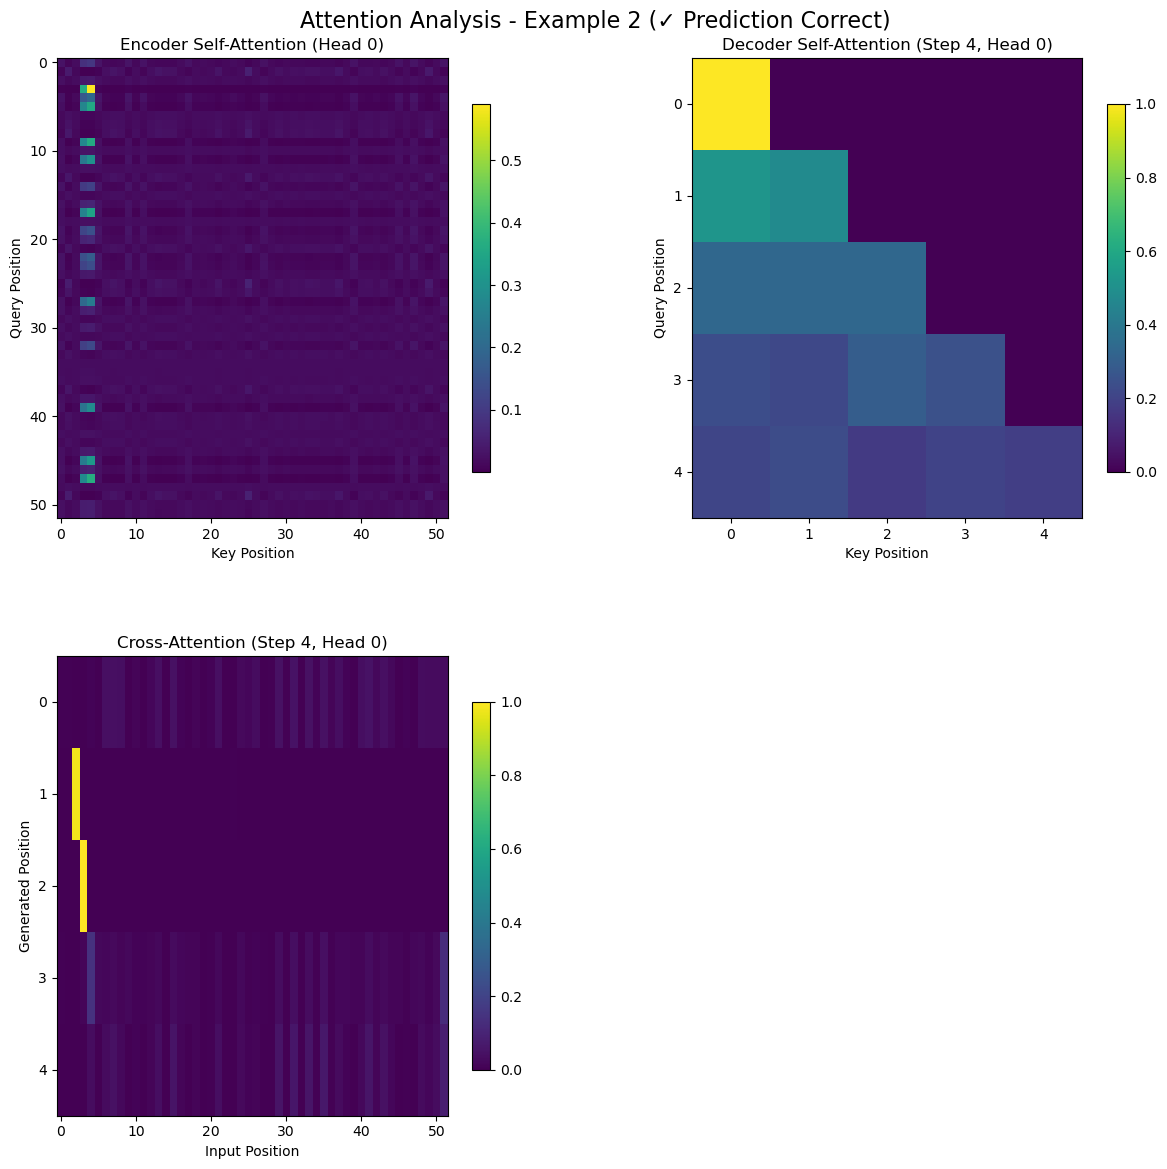

In [3]:
# Example: Analyze data example #15
# this if for all attention heads numbered 0 at step 21 (the 22th token generated in the sequence)
#=================
ex_idx = 2  # the index of the first example to analyze
encoder_att_head = 0  # which encoder self-attention head to analyze
decoder_att_head = 0  # which decoder self-attention head to analyze
cross_att_head = 0  # which cross-attention head to analyze
step = 4 # which token is being generated in the sequence when analyzing cross-attention
# some plotting parameters
figsize = (12,12)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
# outputs = analyze_cross_attention(model, examples, start_idx=start_idx, step=step, att_head=att_head, num_examples=num_examples)
print(f"Input: {tokenizer.decode_sequence(examples['inputs'][ex_idx])}")
print(f"Target: {tokenizer.decode_sequence(examples['targets'][ex_idx])}")
outputs = attention_example(model, examples, ex_idx=ex_idx, step=step, encoder_att_head=encoder_att_head, decoder_att_head=decoder_att_head, cross_att_head=cross_att_head, figsize=figsize, cmap=cmap)

### Example 2b. Visualize Cross Attentions for a Batch of Examples

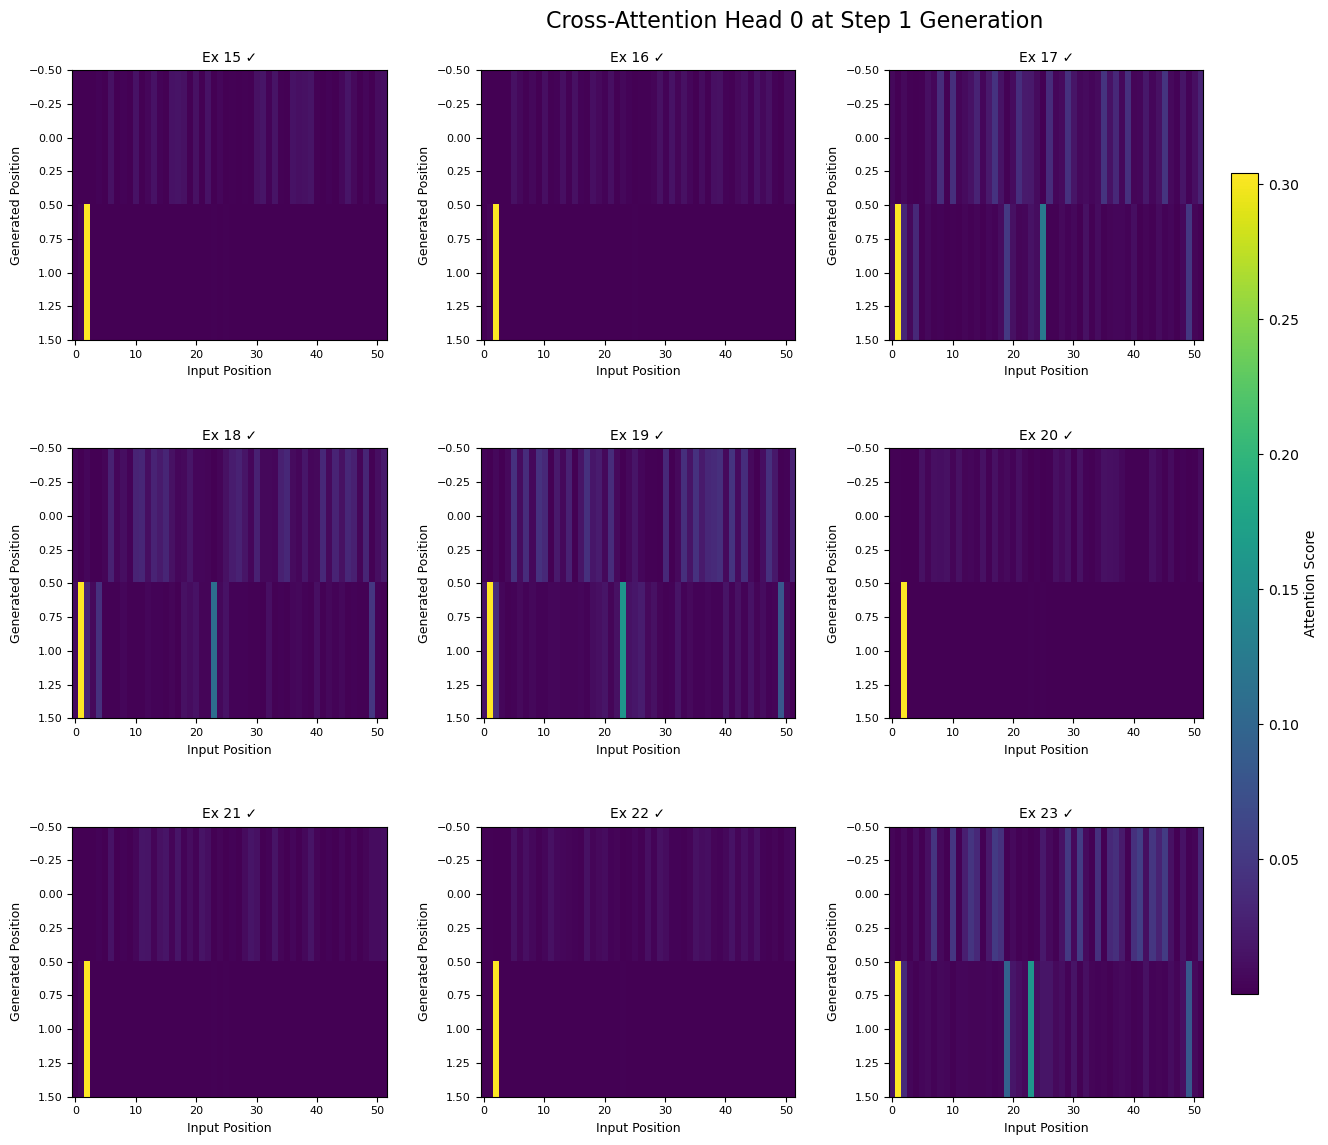

In [4]:
# Example: Analyze 9 examples starting from example #15
# this if for attention head 0 at step 21 (the 22th token generated in the sequence)
# The ✓ and ✗ in the title indicate whether the Dyck path is predicted correctly or not
#=================
start_idx = 15  # the index of the first example to analyze
num_examples = 9  # Number of examples to show
att_head = 0    # attention head to visualize
step = 1  # which token is being generated in the sequence when analyzing cross-attention
# some plotting parameters
figsize = (16, 12)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
outputs = analyze_cross_attention(model, examples, start_idx=start_idx, step=step, att_head=att_head, num_examples=num_examples, figsize=figsize, cmap=cmap)

### Example 2c. Visualize encoder self attention for a batch of examples

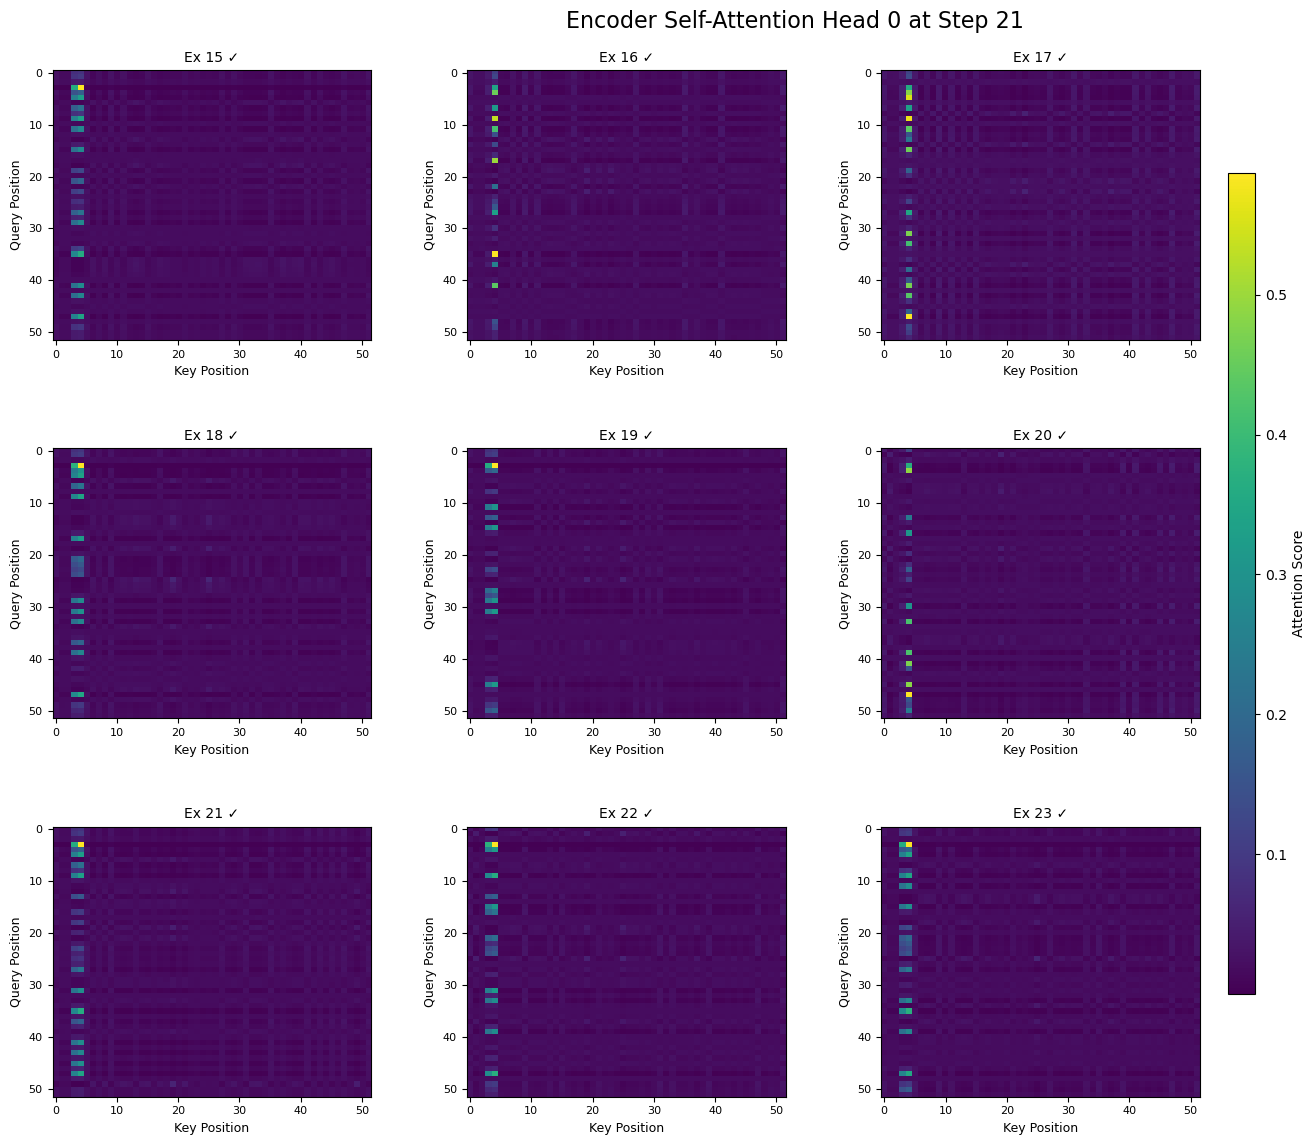

In [5]:
# Example: Analyze 9 examples starting from example #15
# this if for attention head 0 at step 21 (the 22th token generated in the sequence)
# The ✓ and ✗ in the title indicate whether the Dyck path is predicted correctly or not
#=================
start_idx = 15  # the index of the first example to analyze
num_examples = 9  # Number of examples to show
att_head = 0    # attention head to visualize
step = 21  # which token is being generated in the sequence when analyzing attention
# some plotting parameters
figsize = (16, 12)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
outputs = analyze_encoder_attention(model, examples, start_idx=start_idx, step=step, att_head=att_head, num_examples=num_examples, figsize=figsize, cmap=cmap)

### Example 2d. Visualize decoder self attention for a batch of examples

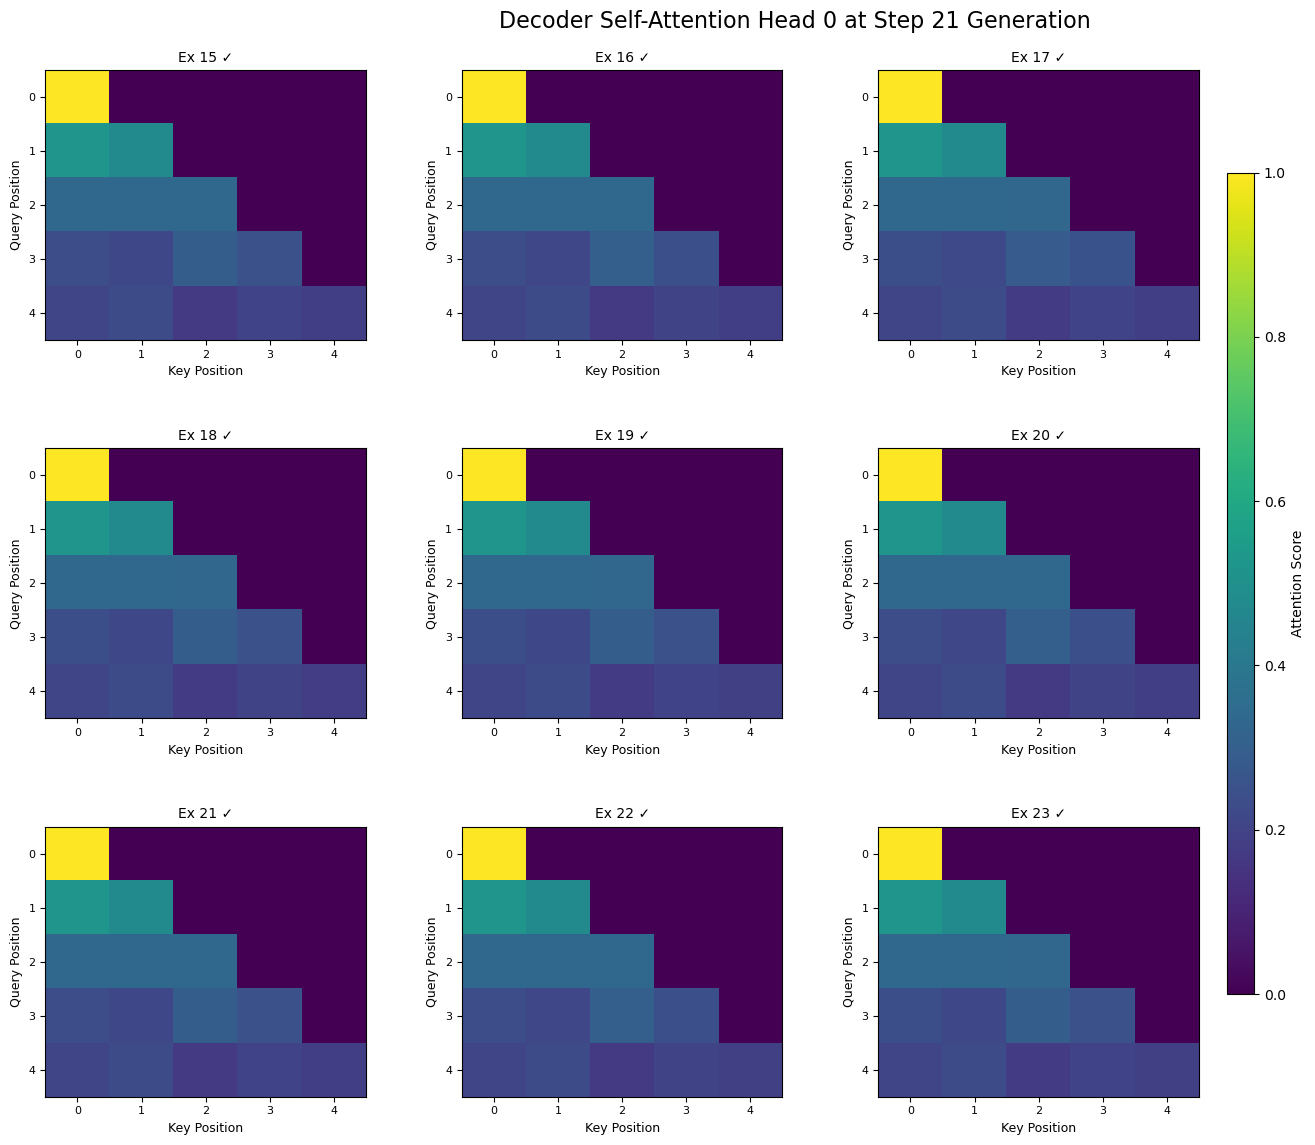

In [6]:
# Example: Analyze 9 examples starting from example #15
# this if for attention head 0 at step 21 (the 22th token generated in the sequence)
# The ✓ and ✗ in the title indicate whether the Dyck path is predicted correctly or not
#=================
start_idx = 15  # the index of the first example to analyze
num_examples = 9  # Number of examples to show
att_head = 0    # attention head to visualize
step = 21  # which token is being generated in the sequence when analyzing attention
# some plotting parameters
figsize = (16, 12)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
outputs = analyze_decoder_attention(model, examples, start_idx=start_idx, step=step, att_head=att_head, num_examples=num_examples, figsize=figsize, cmap=cmap)

### Example 2e. Visualize cross attention across all the steps

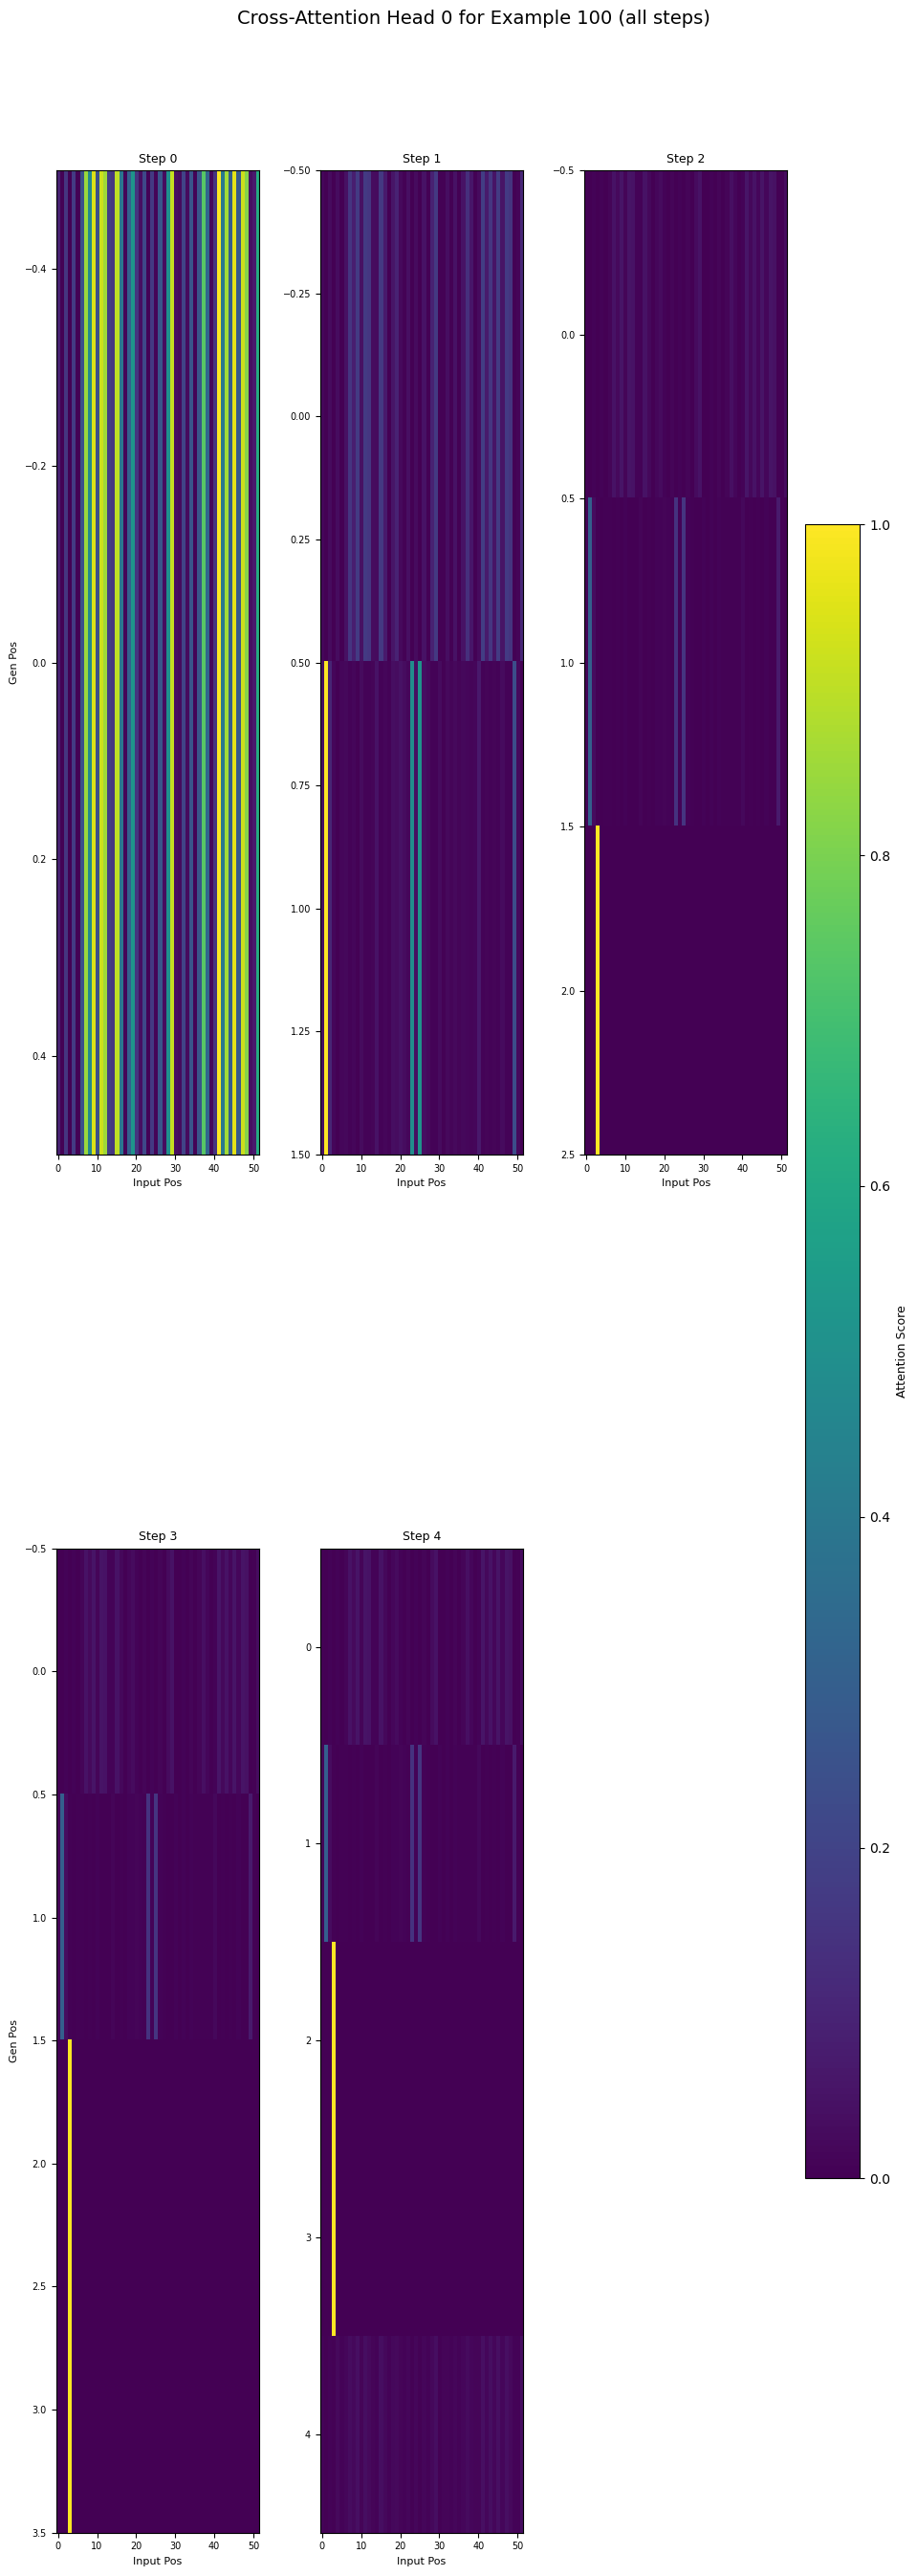

In [7]:
# Example: Analyze example #15
# this if for attention head 0 at step 21 (the 22th token generated in the sequence)
#=================
ex_idx = 100  # the index of the first example to analyze
att_head = 0    # attention head to visualize
# some plotting parameters
figsize = (10,28)  # figure size for visualization
cmap = 'viridis'  # colormap for visualization, e.g. 'Blues', 'inferno', 'viridis'
#=================
outputs = analyze_cross_attention_all_steps(model, examples, ex_idx=ex_idx, att_head=att_head, figsize=figsize, cmap=cmap)

### Example 2f. PCA of encoder and decoder embeddings

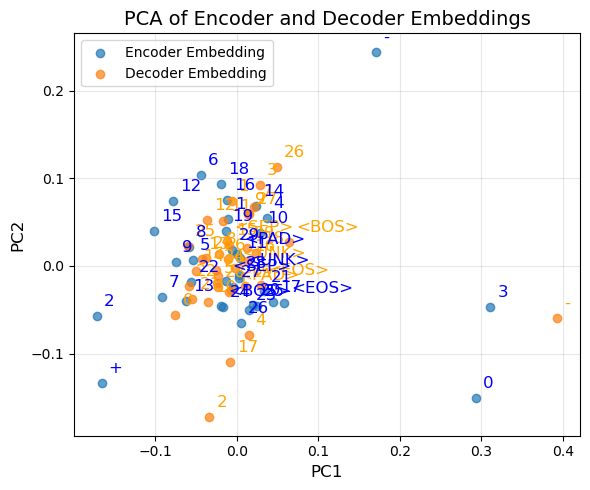

In [8]:
# run a PCA on the encoder and decoder embeddings
outputs = analyze_embeddings_pca(model, tokenizer, figsize=(6, 5), alpha=0.7, fontsize=12)

### Example 2g: PCA of positional embeddings

Positional encoding shape: (52, 128)


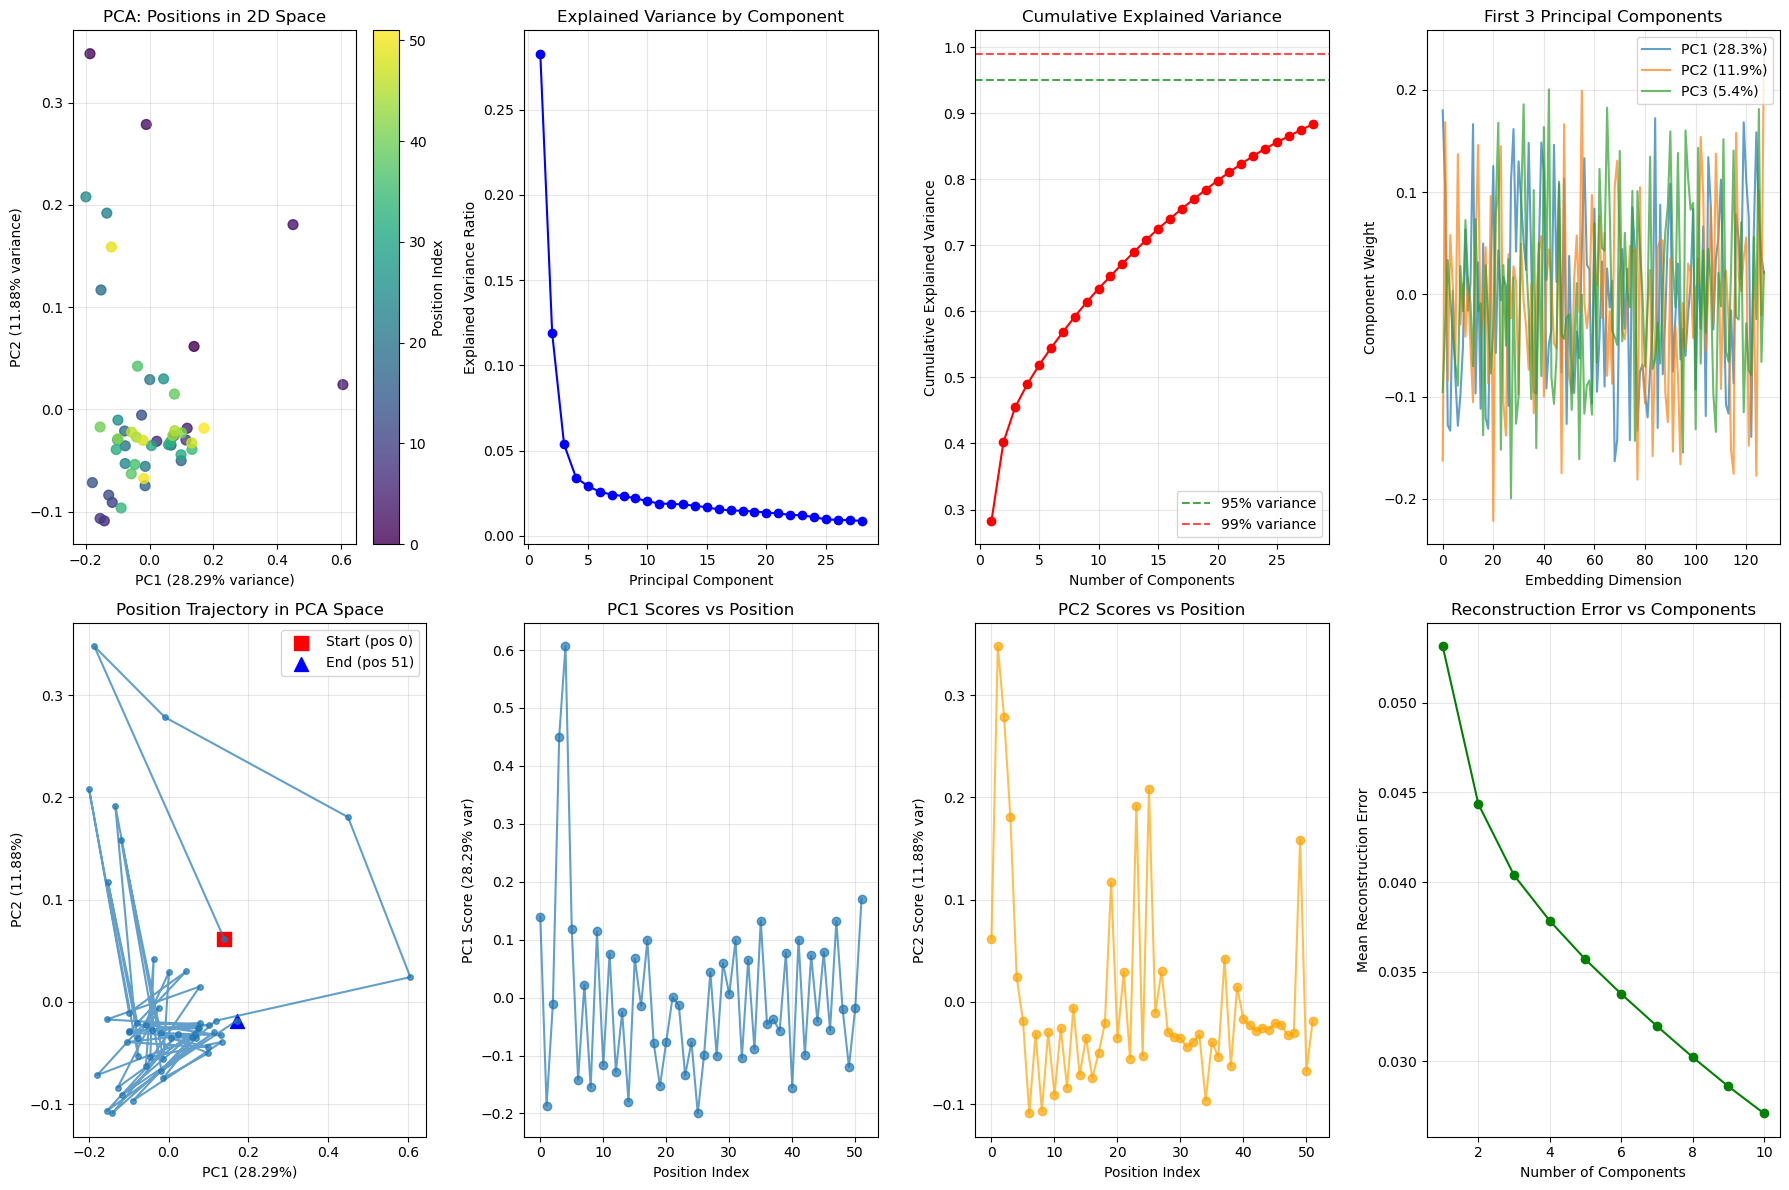


PCA Analysis Summary:
  Original shape: (52, 128)
  Total variance explained by first 2 components: 40.17%
  PC1 explains 28.29% of variance
  PC2 explains 11.88% of variance
  Components needed for 95% variance: 1
  Components needed for 99% variance: 1

First 5 positions in PC space:
  Position 0: PC1=0.140, PC2=0.062
  Position 1: PC1=-0.187, PC2=0.348
  Position 2: PC1=-0.010, PC2=0.279
  Position 3: PC1=0.450, PC2=0.181
  Position 4: PC1=0.607, PC2=0.024

PC space characteristics:
  PC1 range: 0.806
  PC2 range: 0.457
  Aspect ratio (PC1/PC2): 1.766


In [12]:
# PCA of model.src_pos_encoding
from sklearn.decomposition import PCA

# Extract positional encoding weights
pos_encoding_weights = model.src_pos_encoding.pe.weight.data.cpu().numpy()
print(f"Positional encoding shape: {pos_encoding_weights.shape}")

# Perform PCA with multiple components
n_components = min(28, pos_encoding_weights.shape[0], pos_encoding_weights.shape[1])
pca = PCA(n_components=n_components)
pos_pca_full = pca.fit_transform(pos_encoding_weights)

# Also do 2D PCA for visualization
pca_2d = PCA(n_components=2)
pos_pca_2d = pca_2d.fit_transform(pos_encoding_weights)

# Create comprehensive PCA visualization
plt.figure(figsize=(18, 12))

# Plot 1: 2D PCA scatter plot
plt.subplot(2, 4, 1)
scatter = plt.scatter(pos_pca_2d[:, 0], pos_pca_2d[:, 1], c=range(len(pos_pca_2d)), cmap='viridis', alpha=0.8, s=50)
plt.colorbar(scatter, label='Position Index')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA: Positions in 2D Space')
plt.grid(True, alpha=0.3)

# Add position labels for small datasets
if len(pos_pca_2d) <= 30:
    for i, (x, y) in enumerate(pos_pca_2d):
        plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

# Plot 2: Explained variance ratio
plt.subplot(2, 4, 2)
plt.plot(range(1, n_components + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.grid(True, alpha=0.3)

# Plot 3: Cumulative explained variance
plt.subplot(2, 4, 3)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, n_components + 1), cumulative_variance, 'ro-')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95% variance')
plt.axhline(y=0.99, color='r', linestyle='--', alpha=0.7, label='99% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: First few principal components
plt.subplot(2, 4, 4)
for i in range(min(3, n_components)):
    plt.plot(pca.components_[i], label=f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})', alpha=0.7)
plt.xlabel('Embedding Dimension')
plt.ylabel('Component Weight')
plt.title('First 3 Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Position trajectory in PC1-PC2 space
plt.subplot(2, 4, 5)
plt.plot(pos_pca_2d[:, 0], pos_pca_2d[:, 1], 'o-', alpha=0.7, markersize=4)
plt.scatter(pos_pca_2d[0, 0], pos_pca_2d[0, 1], c='red', s=100, marker='s', label='Start (pos 0)')
plt.scatter(pos_pca_2d[-1, 0], pos_pca_2d[-1, 1], c='blue', s=100, marker='^', label=f'End (pos {len(pos_pca_2d)-1})')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.title('Position Trajectory in PCA Space')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: PC1 vs position index
plt.subplot(2, 4, 6)
plt.plot(range(len(pos_pca_2d)), pos_pca_2d[:, 0], 'o-', alpha=0.7)
plt.xlabel('Position Index')
plt.ylabel(f'PC1 Score ({pca_2d.explained_variance_ratio_[0]:.2%} var)')
plt.title('PC1 Scores vs Position')
plt.grid(True, alpha=0.3)

# Plot 7: PC2 vs position index
plt.subplot(2, 4, 7)
plt.plot(range(len(pos_pca_2d)), pos_pca_2d[:, 1], 'o-', alpha=0.7, color='orange')
plt.xlabel('Position Index')
plt.ylabel(f'PC2 Score ({pca_2d.explained_variance_ratio_[1]:.2%} var)')
plt.title('PC2 Scores vs Position')
plt.grid(True, alpha=0.3)

# Plot 8: Reconstruction error
plt.subplot(2, 4, 8)
reconstruction_errors = []
for n in range(1, min(n_components, 10) + 1):
    pca_temp = PCA(n_components=n)
    transformed = pca_temp.fit_transform(pos_encoding_weights)
    reconstructed = pca_temp.inverse_transform(transformed)
    error = np.mean(np.sum((pos_encoding_weights - reconstructed) ** 2, axis=1))
    reconstruction_errors.append(error)

plt.plot(range(1, len(reconstruction_errors) + 1), reconstruction_errors, 'go-')
plt.xlabel('Number of Components')
plt.ylabel('Mean Reconstruction Error')
plt.title('Reconstruction Error vs Components')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\nPCA Analysis Summary:")
print(f"  Original shape: {pos_encoding_weights.shape}")
print(f"  Total variance explained by first 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"  PC1 explains {pca_2d.explained_variance_ratio_[0]:.2%} of variance")
print(f"  PC2 explains {pca_2d.explained_variance_ratio_[1]:.2%} of variance")
print(f"  Components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"  Components needed for 99% variance: {np.argmax(cumulative_variance >= 0.99) + 1}")

# Print the first few PC scores
print(f"\nFirst 5 positions in PC space:")
for i in range(min(5, len(pos_pca_2d))):
    print(f"  Position {i}: PC1={pos_pca_2d[i, 0]:.3f}, PC2={pos_pca_2d[i, 1]:.3f}")

# Analyze patterns in PC space
pc1_range = pos_pca_2d[:, 0].max() - pos_pca_2d[:, 0].min()
pc2_range = pos_pca_2d[:, 1].max() - pos_pca_2d[:, 1].min()
print(f"\nPC space characteristics:")
print(f"  PC1 range: {pc1_range:.3f}")
print(f"  PC2 range: {pc2_range:.3f}")
print(f"  Aspect ratio (PC1/PC2): {pc1_range/pc2_range:.3f}")

Positional encoding shape: (52, 128)


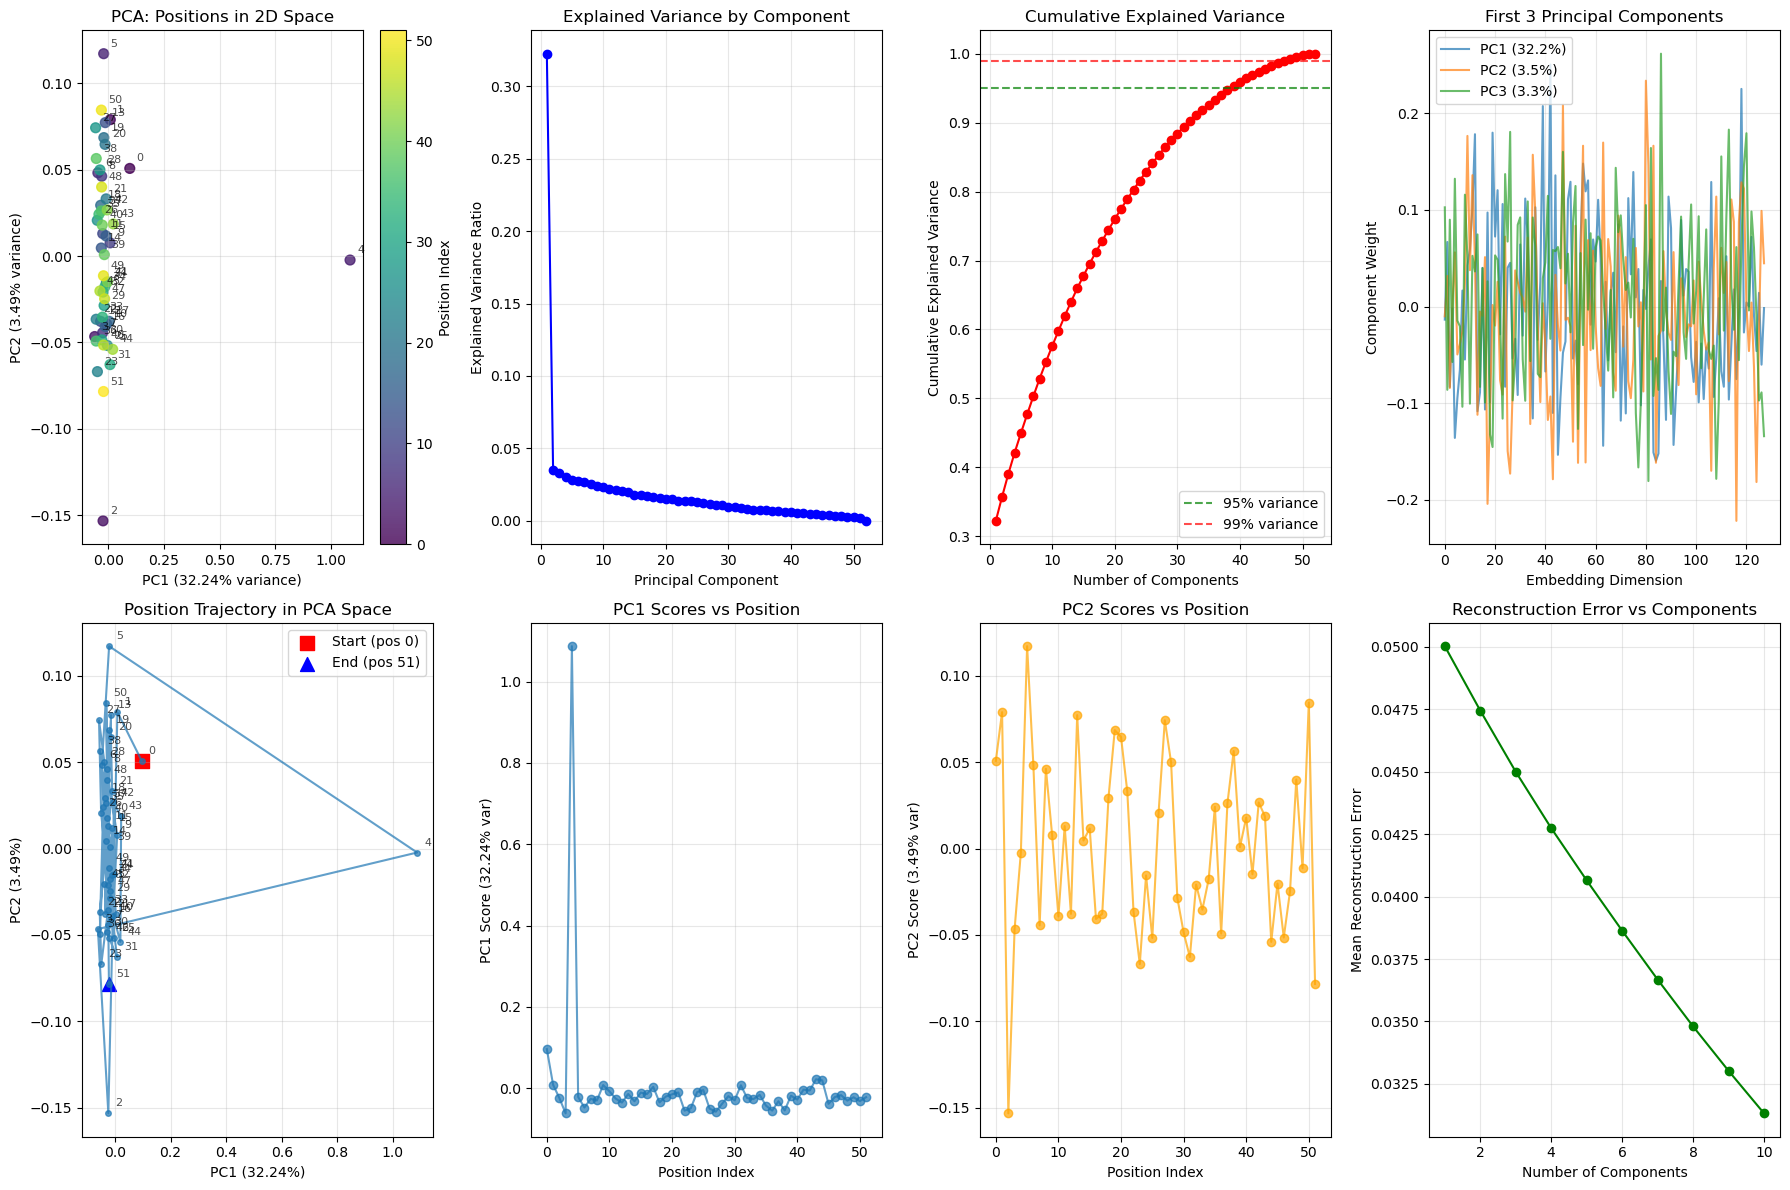


PCA Analysis Summary:
  Original shape: (52, 128)
  Total variance explained by first 2 components: 35.73%
  PC1 explains 32.24% of variance
  PC2 explains 3.49% of variance
  Components needed for 95% variance: 39
  Components needed for 99% variance: 48

First 5 positions in PC space:
  Position 0: PC1=0.096, PC2=0.051
  Position 1: PC1=0.008, PC2=0.079
  Position 2: PC1=-0.024, PC2=-0.153
  Position 3: PC1=-0.062, PC2=-0.047
  Position 4: PC1=1.087, PC2=-0.002

PC space characteristics:
  PC1 range: 1.149
  PC2 range: 0.270
  Aspect ratio (PC1/PC2): 4.251


In [13]:
# PCA of model.tgt_pos_encoding
from sklearn.decomposition import PCA

# Extract positional encoding weights
pos_encoding_weights = model.tgt_pos_encoding.pe.weight.data.cpu().numpy()
print(f"Positional encoding shape: {pos_encoding_weights.shape}")

# Perform PCA with multiple components
n_components = min(56, pos_encoding_weights.shape[0], pos_encoding_weights.shape[1])
pca = PCA(n_components=n_components)
pos_pca_full = pca.fit_transform(pos_encoding_weights)

# Also do 2D PCA for visualization
pca_2d = PCA(n_components=2)
pos_pca_2d = pca_2d.fit_transform(pos_encoding_weights)

# Create comprehensive PCA visualization
plt.figure(figsize=(18, 12))

# Plot 1: 2D PCA scatter plot
plt.subplot(2, 4, 1)
scatter = plt.scatter(pos_pca_2d[:, 0], pos_pca_2d[:, 1], c=range(len(pos_pca_2d)), cmap='viridis', alpha=0.8, s=50)
plt.colorbar(scatter, label='Position Index')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA: Positions in 2D Space')
plt.grid(True, alpha=0.3)

# Add position labels for small datasets
# if len(pos_pca_2d) <= 30:
#     for i, (x, y) in enumerate(pos_pca_2d):
#         plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
for i, (x, y) in enumerate(pos_pca_2d):
        plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)


# Plot 2: Explained variance ratio
plt.subplot(2, 4, 2)
plt.plot(range(1, n_components + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')
plt.grid(True, alpha=0.3)

# Plot 3: Cumulative explained variance
plt.subplot(2, 4, 3)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, n_components + 1), cumulative_variance, 'ro-')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95% variance')
plt.axhline(y=0.99, color='r', linestyle='--', alpha=0.7, label='99% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: First few principal components
plt.subplot(2, 4, 4)
for i in range(min(3, n_components)):
    plt.plot(pca.components_[i], label=f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})', alpha=0.7)
plt.xlabel('Embedding Dimension')
plt.ylabel('Component Weight')
plt.title('First 3 Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Position trajectory in PC1-PC2 space
plt.subplot(2, 4, 5)
plt.plot(pos_pca_2d[:, 0], pos_pca_2d[:, 1], 'o-', alpha=0.7, markersize=4)
plt.scatter(pos_pca_2d[0, 0], pos_pca_2d[0, 1], c='red', s=100, marker='s', label='Start (pos 0)')
plt.scatter(pos_pca_2d[-1, 0], pos_pca_2d[-1, 1], c='blue', s=100, marker='^', label=f'End (pos {len(pos_pca_2d)-1})')
for i, (x, y) in enumerate(pos_pca_2d):
        plt.annotate(str(i), (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.title('Position Trajectory in PCA Space')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: PC1 vs position index
plt.subplot(2, 4, 6)
plt.plot(range(len(pos_pca_2d)), pos_pca_2d[:, 0], 'o-', alpha=0.7)
plt.xlabel('Position Index')
plt.ylabel(f'PC1 Score ({pca_2d.explained_variance_ratio_[0]:.2%} var)')
plt.title('PC1 Scores vs Position')
plt.grid(True, alpha=0.3)

# Plot 7: PC2 vs position index
plt.subplot(2, 4, 7)
plt.plot(range(len(pos_pca_2d)), pos_pca_2d[:, 1], 'o-', alpha=0.7, color='orange')
plt.xlabel('Position Index')
plt.ylabel(f'PC2 Score ({pca_2d.explained_variance_ratio_[1]:.2%} var)')
plt.title('PC2 Scores vs Position')
plt.grid(True, alpha=0.3)

# Plot 8: Reconstruction error
plt.subplot(2, 4, 8)
reconstruction_errors = []
for n in range(1, min(n_components, 10) + 1):
    pca_temp = PCA(n_components=n)
    transformed = pca_temp.fit_transform(pos_encoding_weights)
    reconstructed = pca_temp.inverse_transform(transformed)
    error = np.mean(np.sum((pos_encoding_weights - reconstructed) ** 2, axis=1))
    reconstruction_errors.append(error)

plt.plot(range(1, len(reconstruction_errors) + 1), reconstruction_errors, 'go-')
plt.xlabel('Number of Components')
plt.ylabel('Mean Reconstruction Error')
plt.title('Reconstruction Error vs Components')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"\nPCA Analysis Summary:")
print(f"  Original shape: {pos_encoding_weights.shape}")
print(f"  Total variance explained by first 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"  PC1 explains {pca_2d.explained_variance_ratio_[0]:.2%} of variance")
print(f"  PC2 explains {pca_2d.explained_variance_ratio_[1]:.2%} of variance")
print(f"  Components needed for 95% variance: {np.argmax(cumulative_variance >= 0.95) + 1}")
print(f"  Components needed for 99% variance: {np.argmax(cumulative_variance >= 0.99) + 1}")

# Print the first few PC scores
print(f"\nFirst 5 positions in PC space:")
for i in range(min(5, len(pos_pca_2d))):
    print(f"  Position {i}: PC1={pos_pca_2d[i, 0]:.3f}, PC2={pos_pca_2d[i, 1]:.3f}")

# Analyze patterns in PC space
pc1_range = pos_pca_2d[:, 0].max() - pos_pca_2d[:, 0].min()
pc2_range = pos_pca_2d[:, 1].max() - pos_pca_2d[:, 1].min()
print(f"\nPC space characteristics:")
print(f"  PC1 range: {pc1_range:.3f}")
print(f"  PC2 range: {pc2_range:.3f}")
print(f"  Aspect ratio (PC1/PC2): {pc1_range/pc2_range:.3f}")

Positional encoding shape: (52, 128)


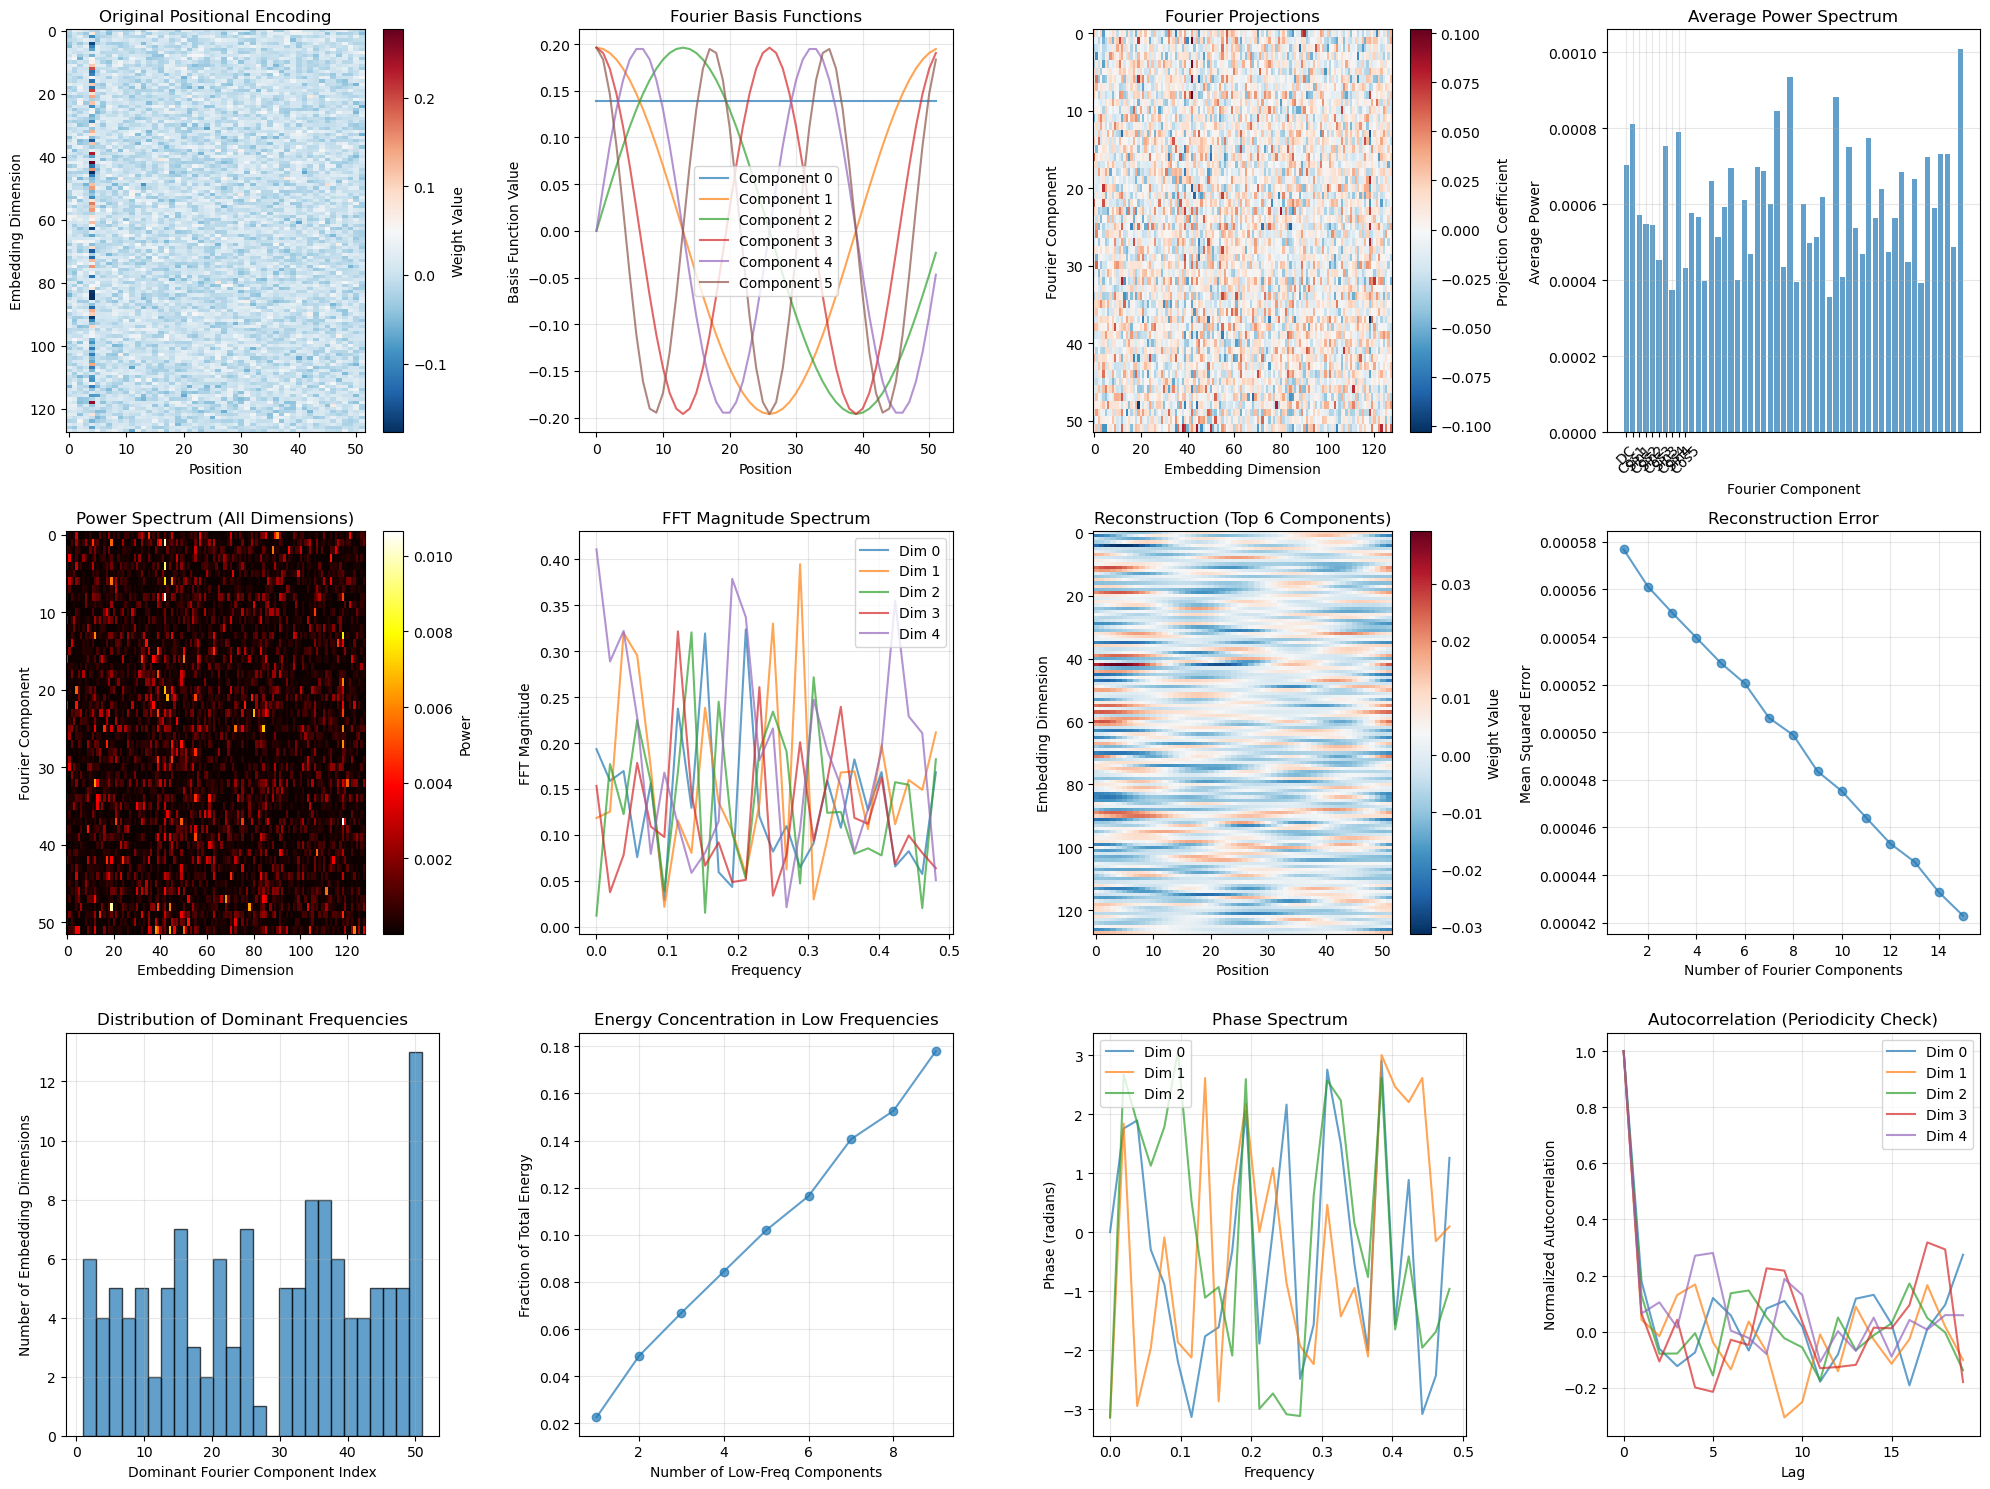


Fourier Analysis Summary:
  Shape: (52, 128)
  Number of Fourier components: 52
  DC component average: -0.0020
  DC component std: 0.0264

Top 5 most periodic embedding dimensions: [ 12  39  19 118  42]
Their periodic strength scores: [0.00140421 0.00156876 0.00172837 0.00228418 0.0025237 ]

Energy distribution:
  DC component energy: 2.25%
  Low frequency (first 5) energy: 10.19%
  High frequency energy: 89.81%

Dominant frequency analysis:
  Most common dominant frequency component: 51
  Number of dimensions with this frequency: 12
  Frequency diversity (unique dominant freqs): 45

Comparison to sinusoidal patterns:
  Energy in sine/cosine components vs DC: 43.38
  Average reconstruction error with 6 components: 0.000520
  Relative reconstruction error: 88.18%


In [14]:
# Fourier basis projection of model.tgt_pos_encoding
import numpy as np
from scipy.fft import fft, fftfreq, fft2
from scipy.linalg import dft

# Extract positional encoding weights
pos_encoding_weights = model.tgt_pos_encoding.pe.weight.data.cpu().numpy()
n_positions, d_model = pos_encoding_weights.shape
print(f"Positional encoding shape: {pos_encoding_weights.shape}")

# Create Fourier basis functions
def create_fourier_basis(n_positions, n_components):
    """Create Fourier basis functions for projection"""
    basis = np.zeros((n_positions, n_components))
    
    # DC component
    basis[:, 0] = 1.0 / np.sqrt(n_positions)
    
    # Sine and cosine components
    for k in range(1, n_components // 2 + 1):
        if 2*k-1 < n_components:
            # Cosine component
            basis[:, 2*k-1] = np.sqrt(2/n_positions) * np.cos(2*np.pi*k*np.arange(n_positions)/n_positions)
        if 2*k < n_components:
            # Sine component  
            basis[:, 2*k] = np.sqrt(2/n_positions) * np.sin(2*np.pi*k*np.arange(n_positions)/n_positions)
    
    return basis

# Number of Fourier components to use
n_fourier_components = n_positions
fourier_basis = create_fourier_basis(n_positions, n_fourier_components)

# Project each embedding dimension onto Fourier basis
fourier_projections = np.dot(fourier_basis.T, pos_encoding_weights)  # Shape: (n_fourier_components, d_model)

# Compute power spectrum for each embedding dimension
power_spectra = fourier_projections ** 2

# Average power spectrum across all embedding dimensions
avg_power_spectrum = np.mean(power_spectra, axis=1)

# Also compute FFT for each embedding dimension
fft_results = np.abs(fft(pos_encoding_weights, axis=0))
frequencies = fftfreq(n_positions, 1.0)

# Create comprehensive visualization
plt.figure(figsize=(20, 15))

# Plot 1: Original positional encoding heatmap
plt.subplot(3, 4, 1)
im = plt.imshow(pos_encoding_weights.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, label='Weight Value')
plt.xlabel('Position')
plt.ylabel('Embedding Dimension')
plt.title('Original Positional Encoding')

# Plot 2: Fourier basis functions (first few)
plt.subplot(3, 4, 2)
for i in range(min(6, n_fourier_components)):
    plt.plot(fourier_basis[:, i], label=f'Component {i}', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Basis Function Value')
plt.title('Fourier Basis Functions')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Fourier projections heatmap
plt.subplot(3, 4, 3)
im = plt.imshow(fourier_projections, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, label='Projection Coefficient')
plt.xlabel('Embedding Dimension')
plt.ylabel('Fourier Component')
plt.title('Fourier Projections')

# Plot 4: Average power spectrum
plt.subplot(3, 4, 4)
component_labels = ['DC'] + [f'Cos{i//2+1}' if i%2==1 else f'Sin{i//2}' for i in range(1, len(avg_power_spectrum))]
plt.bar(range(len(avg_power_spectrum)), avg_power_spectrum, alpha=0.7)
plt.xlabel('Fourier Component')
plt.ylabel('Average Power')
plt.title('Average Power Spectrum')
plt.xticks(range(min(10, len(component_labels))), component_labels[:min(10, len(component_labels))], rotation=45)
plt.grid(True, alpha=0.3)

# Plot 5: Power spectrum for each embedding dimension
plt.subplot(3, 4, 5)
im = plt.imshow(power_spectra, aspect='auto', cmap='hot', interpolation='nearest')
plt.colorbar(im, label='Power')
plt.xlabel('Embedding Dimension')
plt.ylabel('Fourier Component')
plt.title('Power Spectrum (All Dimensions)')

# Plot 6: FFT magnitude spectrum (first few dims)
plt.subplot(3, 4, 6)
for i in range(min(5, d_model)):
    plt.plot(frequencies[:n_positions//2], fft_results[:n_positions//2, i], 
             label=f'Dim {i}', alpha=0.7)
plt.xlabel('Frequency')
plt.ylabel('FFT Magnitude')
plt.title('FFT Magnitude Spectrum')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 7: Reconstruction using top Fourier components
plt.subplot(3, 4, 7)
n_recon_components = min(6, n_fourier_components)
reconstructed = np.dot(fourier_basis[:, :n_recon_components], fourier_projections[:n_recon_components, :])
im = plt.imshow(reconstructed.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
plt.colorbar(im, label='Weight Value')
plt.xlabel('Position')
plt.ylabel('Embedding Dimension')
plt.title(f'Reconstruction (Top {n_recon_components} Components)')

# Plot 8: Reconstruction error
plt.subplot(3, 4, 8)
reconstruction_errors = []
component_counts = range(1, min(n_fourier_components, 15) + 1)
for n_comp in component_counts:
    recon = np.dot(fourier_basis[:, :n_comp], fourier_projections[:n_comp, :])
    error = np.mean((pos_encoding_weights - recon) ** 2)
    reconstruction_errors.append(error)

plt.plot(component_counts, reconstruction_errors, 'o-', alpha=0.7)
plt.xlabel('Number of Fourier Components')
plt.ylabel('Mean Squared Error')
plt.title('Reconstruction Error')
plt.grid(True, alpha=0.3)

# Plot 9: Dominant frequencies for each embedding dimension
plt.subplot(3, 4, 9)
dominant_freqs = []
for i in range(d_model):
    # Find the dominant frequency component (excluding DC)
    power_spectrum_dim = power_spectra[1:, i]  # Exclude DC component
    dominant_idx = np.argmax(power_spectrum_dim) + 1  # +1 because we excluded DC
    dominant_freqs.append(dominant_idx)

plt.hist(dominant_freqs, bins=n_fourier_components//2, alpha=0.7, edgecolor='black')
plt.xlabel('Dominant Fourier Component Index')
plt.ylabel('Number of Embedding Dimensions')
plt.title('Distribution of Dominant Frequencies')
plt.grid(True, alpha=0.3)

# Plot 10: Energy concentration
plt.subplot(3, 4, 10)
# Calculate what fraction of energy is in low-frequency components
low_freq_energy = []
for threshold in range(1, min(10, n_fourier_components)):
    energy_ratio = np.sum(power_spectra[:threshold, :]) / np.sum(power_spectra)
    low_freq_energy.append(energy_ratio)

plt.plot(range(1, len(low_freq_energy) + 1), low_freq_energy, 'o-', alpha=0.7)
plt.xlabel('Number of Low-Freq Components')
plt.ylabel('Fraction of Total Energy')
plt.title('Energy Concentration in Low Frequencies')
plt.grid(True, alpha=0.3)

# Plot 11: Phase analysis (for complex FFT)
plt.subplot(3, 4, 11)
complex_fft = fft(pos_encoding_weights, axis=0)
phases = np.angle(complex_fft)
# Plot phase for first few embedding dimensions
for i in range(min(3, d_model)):
    plt.plot(frequencies[:n_positions//2], phases[:n_positions//2, i], 
             label=f'Dim {i}', alpha=0.7)
plt.xlabel('Frequency')
plt.ylabel('Phase (radians)')
plt.title('Phase Spectrum')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 12: Periodic pattern detection
plt.subplot(3, 4, 12)
# Check for periodicity by computing autocorrelation
autocorr_results = []
for i in range(min(5, d_model)):
    signal = pos_encoding_weights[:, i]
    autocorr = np.correlate(signal, signal, mode='full')
    autocorr = autocorr[autocorr.size // 2:]
    autocorr_results.append(autocorr / autocorr[0])  # Normalize

for i, autocorr in enumerate(autocorr_results):
    plt.plot(autocorr[:min(20, len(autocorr))], label=f'Dim {i}', alpha=0.7)
plt.xlabel('Lag')
plt.ylabel('Normalized Autocorrelation')
plt.title('Autocorrelation (Periodicity Check)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed analysis
print(f"\nFourier Analysis Summary:")
print(f"  Shape: {pos_encoding_weights.shape}")
print(f"  Number of Fourier components: {n_fourier_components}")
print(f"  DC component average: {np.mean(fourier_projections[0, :]):.4f}")
print(f"  DC component std: {np.std(fourier_projections[0, :]):.4f}")

# Find dimensions with strongest periodic patterns
periodic_strength = np.std(power_spectra[1:, :], axis=0)  # Exclude DC, measure variation in frequency domain
top_periodic_dims = np.argsort(periodic_strength)[-5:]
print(f"\nTop 5 most periodic embedding dimensions: {top_periodic_dims}")
print(f"Their periodic strength scores: {periodic_strength[top_periodic_dims]}")

# Energy distribution
total_energy = np.sum(power_spectra)
dc_energy = np.sum(power_spectra[0, :])
low_freq_energy_total = np.sum(power_spectra[:min(5, n_fourier_components), :])
print(f"\nEnergy distribution:")
print(f"  DC component energy: {dc_energy/total_energy:.2%}")
print(f"  Low frequency (first 5) energy: {low_freq_energy_total/total_energy:.2%}")
print(f"  High frequency energy: {(total_energy-low_freq_energy_total)/total_energy:.2%}")

# Dominant frequency analysis
print(f"\nDominant frequency analysis:")
print(f"  Most common dominant frequency component: {np.bincount(dominant_freqs).argmax()}")
print(f"  Number of dimensions with this frequency: {np.max(np.bincount(dominant_freqs))}")
print(f"  Frequency diversity (unique dominant freqs): {len(np.unique(dominant_freqs))}")

# Check if learned encodings resemble sinusoidal patterns
print(f"\nComparison to sinusoidal patterns:")
print(f"  Energy in sine/cosine components vs DC: {(total_energy-dc_energy)/dc_energy:.2f}")
print(f"  Average reconstruction error with 6 components: {reconstruction_errors[5]:.6f}")
print(f"  Relative reconstruction error: {reconstruction_errors[5]/np.var(pos_encoding_weights):.2%}")

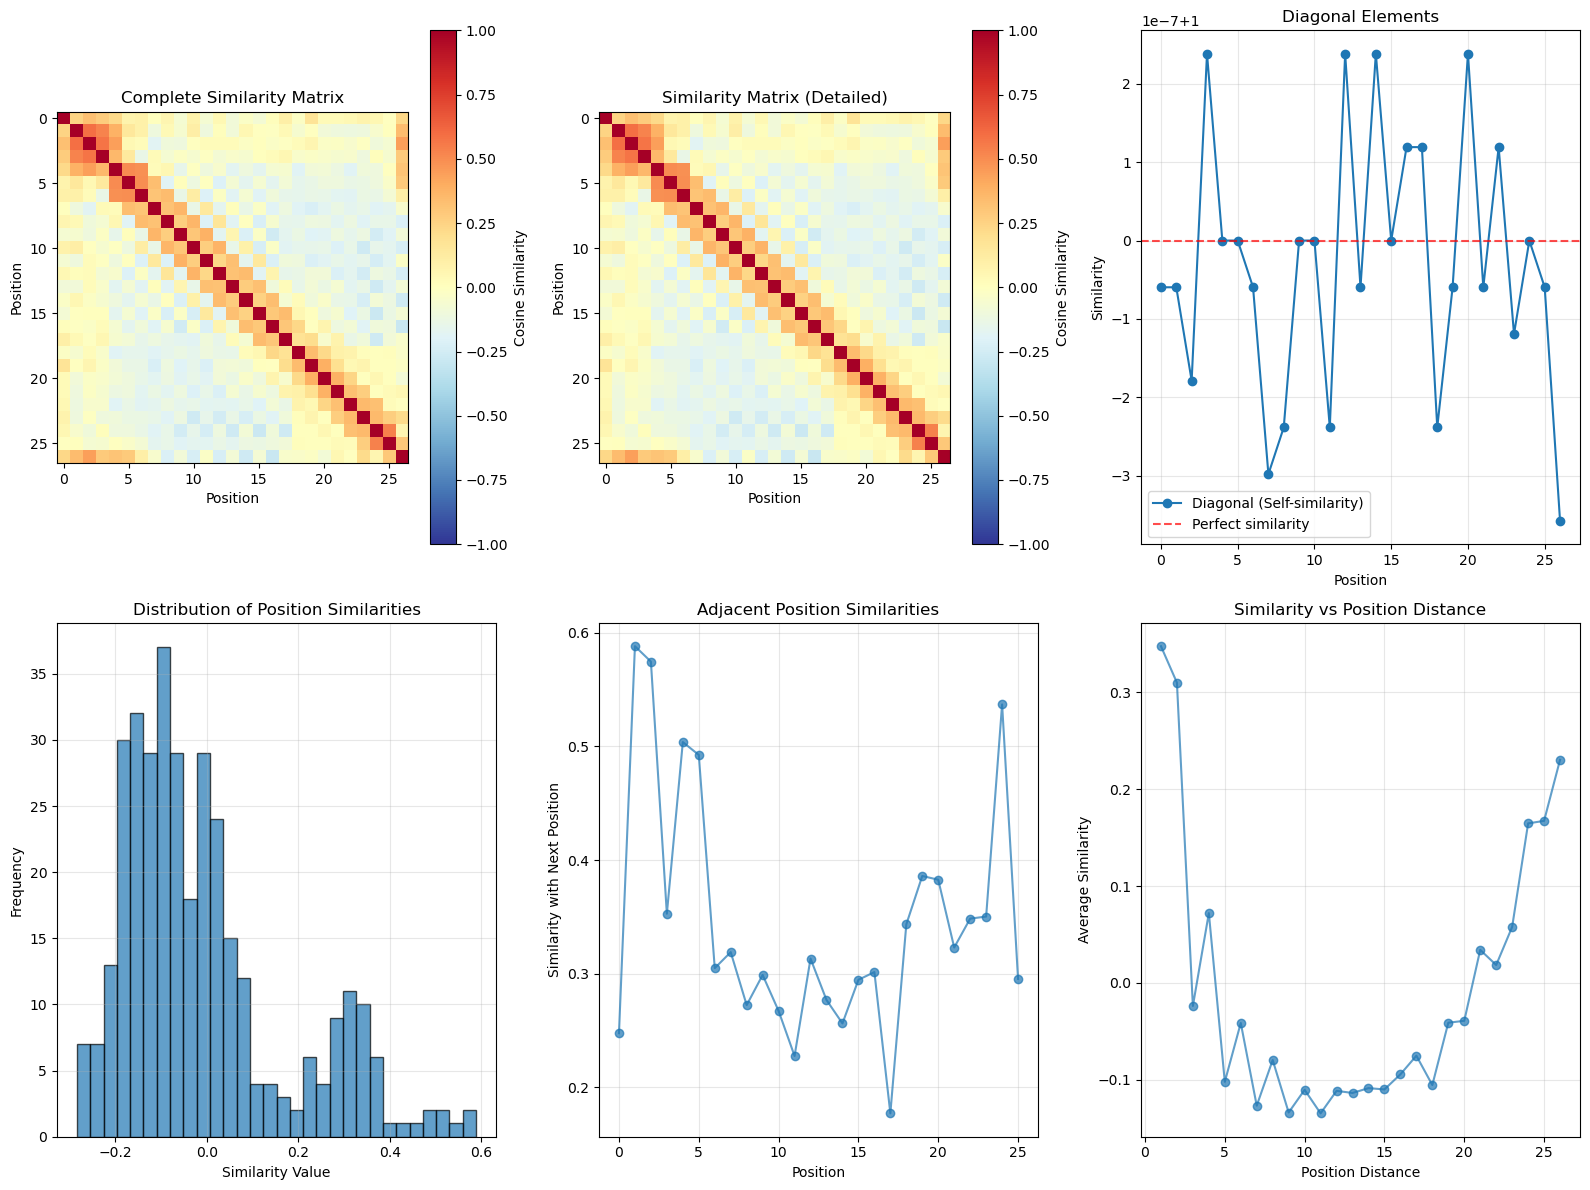

Positional Encoding Similarity Analysis:
  Shape: (27, 128)
  Similarity matrix shape: (27, 27)
  Average similarity (excluding diagonal): -0.0099
  Std of similarities: 0.1805
  Min similarity: -0.2836
  Max similarity: 0.5883
  Average adjacent similarity: 0.3475
  Most similar pair: positions (np.int64(1), np.int64(2)) with similarity 0.5883
  Least similar pair: positions (np.int64(16), np.int64(26)) with similarity -0.2836


In [19]:
# Extract positional encoding weights
pos_encoding_weights = model.src_pos_encoding.pe.weight.data.cpu().numpy()
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix
similarity_matrix = cosine_similarity(pos_encoding_weights)

# Create comprehensive similarity analysis
plt.figure(figsize=(16, 12))

# Plot 1: Full similarity matrix
plt.subplot(2, 3, 1)
im1 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar(im1, label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Complete Similarity Matrix')

# Plot 2: Similarity matrix with annotations for small matrices
plt.subplot(2, 3, 2)
if similarity_matrix.shape[0] <= 20:  # Only annotate if matrix is small enough
    im2 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
    # Add text annotations
    for i in range(similarity_matrix.shape[0]):
        for j in range(similarity_matrix.shape[1]):
            plt.text(j, i, f'{similarity_matrix[i, j]:.2f}', 
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(similarity_matrix[i, j]) > 0.5 else 'black')
    plt.colorbar(im2, label='Cosine Similarity')
else:
    im2 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
    plt.colorbar(im2, label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Similarity Matrix (Detailed)')

# Plot 3: Diagonal analysis (self-similarity should be 1)
plt.subplot(2, 3, 3)
diagonal = np.diag(similarity_matrix)
plt.plot(diagonal, 'o-', label='Diagonal (Self-similarity)')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Perfect similarity')
plt.xlabel('Position')
plt.ylabel('Similarity')
plt.title('Diagonal Elements')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Off-diagonal similarities
plt.subplot(2, 3, 4)
# Extract upper triangle (excluding diagonal)
upper_triangle = similarity_matrix[np.triu_indices(similarity_matrix.shape[0], k=1)]
plt.hist(upper_triangle, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Similarity Value')
plt.ylabel('Frequency')
plt.title('Distribution of Position Similarities')
plt.grid(True, alpha=0.3)

# Plot 5: Adjacent position similarities
plt.subplot(2, 3, 5)
adjacent_similarities = [similarity_matrix[i, i+1] for i in range(len(similarity_matrix)-1)]
plt.plot(adjacent_similarities, 'o-', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Similarity with Next Position')
plt.title('Adjacent Position Similarities')
plt.grid(True, alpha=0.3)

# Plot 6: Distance-based similarity analysis
plt.subplot(2, 3, 6)
distances = []
similarities = []
for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        distance = abs(i - j)
        similarity = similarity_matrix[i, j]
        distances.append(distance)
        similarities.append(similarity)

# Group by distance and compute mean similarity
unique_distances = sorted(set(distances))
mean_similarities = []
for d in unique_distances:
    sims_at_distance = [similarities[k] for k, dist in enumerate(distances) if dist == d]
    mean_similarities.append(np.mean(sims_at_distance))

plt.plot(unique_distances, mean_similarities, 'o-', alpha=0.7)
plt.xlabel('Position Distance')
plt.ylabel('Average Similarity')
plt.title('Similarity vs Position Distance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Positional Encoding Similarity Analysis:")
print(f"  Shape: {pos_encoding_weights.shape}")
print(f"  Similarity matrix shape: {similarity_matrix.shape}")
print(f"  Average similarity (excluding diagonal): {np.mean(upper_triangle):.4f}")
print(f"  Std of similarities: {np.std(upper_triangle):.4f}")
print(f"  Min similarity: {np.min(upper_triangle):.4f}")
print(f"  Max similarity: {np.max(upper_triangle):.4f}")
print(f"  Average adjacent similarity: {np.mean(adjacent_similarities):.4f}")
print(f"  Most similar pair: positions {np.unravel_index(np.argmax(similarity_matrix - np.eye(len(similarity_matrix))), similarity_matrix.shape)} with similarity {np.max(similarity_matrix - np.eye(len(similarity_matrix))):.4f}")
print(f"  Least similar pair: positions {np.unravel_index(np.argmin(similarity_matrix), similarity_matrix.shape)} with similarity {np.min(similarity_matrix):.4f}")

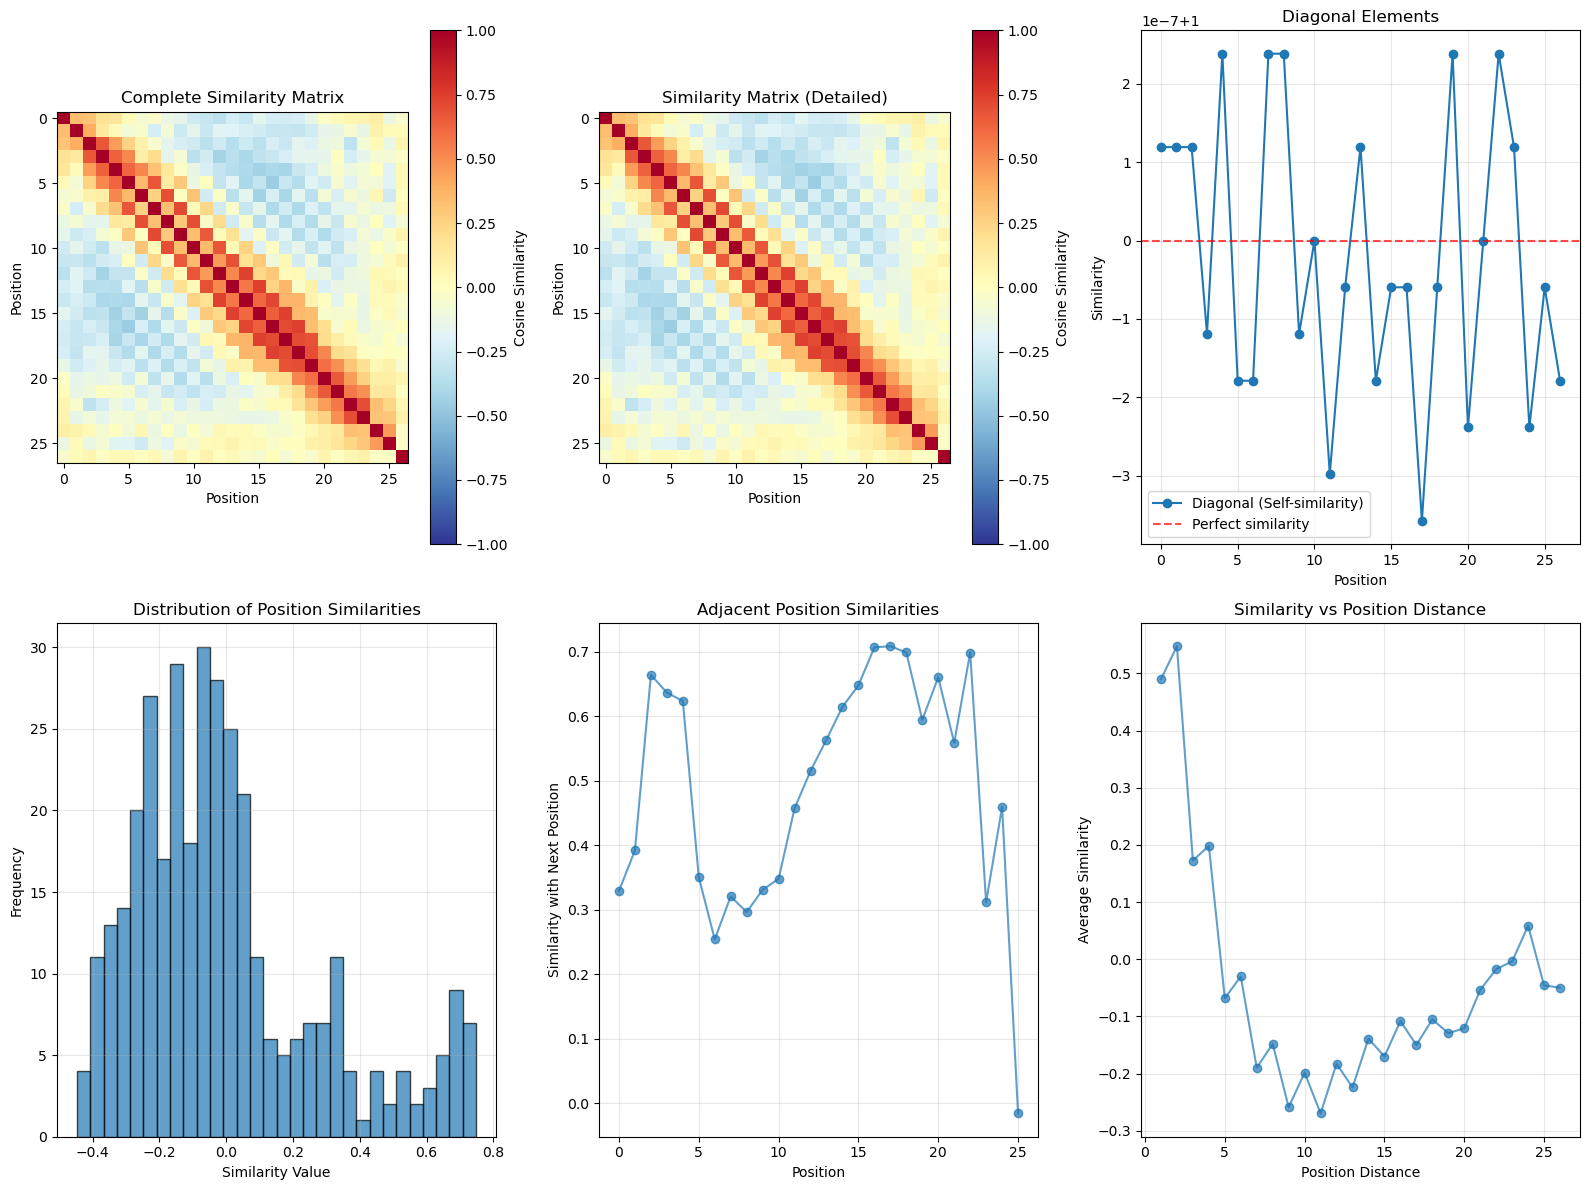

Positional Encoding Similarity Analysis:
  Shape: (27, 128)
  Similarity matrix shape: (27, 27)
  Average similarity (excluding diagonal): -0.0045
  Std of similarities: 0.2805
  Min similarity: -0.4465
  Max similarity: 0.7481
  Average adjacent similarity: 0.4897
  Most similar pair: positions (np.int64(13), np.int64(15)) with similarity 0.7481
  Least similar pair: positions (np.int64(5), np.int64(16)) with similarity -0.4465


In [47]:
# Extract positional encoding weights
pos_encoding_weights = model.tgt_pos_encoding.pe.weight.data.cpu().numpy()
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix
similarity_matrix = cosine_similarity(pos_encoding_weights)

# Create comprehensive similarity analysis
plt.figure(figsize=(16, 12))

# Plot 1: Full similarity matrix
plt.subplot(2, 3, 1)
im1 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar(im1, label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Complete Similarity Matrix')

# Plot 2: Similarity matrix with annotations for small matrices
plt.subplot(2, 3, 2)
if similarity_matrix.shape[0] <= 20:  # Only annotate if matrix is small enough
    im2 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
    # Add text annotations
    for i in range(similarity_matrix.shape[0]):
        for j in range(similarity_matrix.shape[1]):
            plt.text(j, i, f'{similarity_matrix[i, j]:.2f}', 
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(similarity_matrix[i, j]) > 0.5 else 'black')
    plt.colorbar(im2, label='Cosine Similarity')
else:
    im2 = plt.imshow(similarity_matrix, cmap='RdYlBu_r', interpolation='nearest', vmin=-1, vmax=1)
    plt.colorbar(im2, label='Cosine Similarity')
plt.xlabel('Position')
plt.ylabel('Position')
plt.title('Similarity Matrix (Detailed)')

# Plot 3: Diagonal analysis (self-similarity should be 1)
plt.subplot(2, 3, 3)
diagonal = np.diag(similarity_matrix)
plt.plot(diagonal, 'o-', label='Diagonal (Self-similarity)')
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Perfect similarity')
plt.xlabel('Position')
plt.ylabel('Similarity')
plt.title('Diagonal Elements')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Off-diagonal similarities
plt.subplot(2, 3, 4)
# Extract upper triangle (excluding diagonal)
upper_triangle = similarity_matrix[np.triu_indices(similarity_matrix.shape[0], k=1)]
plt.hist(upper_triangle, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Similarity Value')
plt.ylabel('Frequency')
plt.title('Distribution of Position Similarities')
plt.grid(True, alpha=0.3)

# Plot 5: Adjacent position similarities
plt.subplot(2, 3, 5)
adjacent_similarities = [similarity_matrix[i, i+1] for i in range(len(similarity_matrix)-1)]
plt.plot(adjacent_similarities, 'o-', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Similarity with Next Position')
plt.title('Adjacent Position Similarities')
plt.grid(True, alpha=0.3)

# Plot 6: Distance-based similarity analysis
plt.subplot(2, 3, 6)
distances = []
similarities = []
for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        distance = abs(i - j)
        similarity = similarity_matrix[i, j]
        distances.append(distance)
        similarities.append(similarity)

# Group by distance and compute mean similarity
unique_distances = sorted(set(distances))
mean_similarities = []
for d in unique_distances:
    sims_at_distance = [similarities[k] for k, dist in enumerate(distances) if dist == d]
    mean_similarities.append(np.mean(sims_at_distance))

plt.plot(unique_distances, mean_similarities, 'o-', alpha=0.7)
plt.xlabel('Position Distance')
plt.ylabel('Average Similarity')
plt.title('Similarity vs Position Distance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Positional Encoding Similarity Analysis:")
print(f"  Shape: {pos_encoding_weights.shape}")
print(f"  Similarity matrix shape: {similarity_matrix.shape}")
print(f"  Average similarity (excluding diagonal): {np.mean(upper_triangle):.4f}")
print(f"  Std of similarities: {np.std(upper_triangle):.4f}")
print(f"  Min similarity: {np.min(upper_triangle):.4f}")
print(f"  Max similarity: {np.max(upper_triangle):.4f}")
print(f"  Average adjacent similarity: {np.mean(adjacent_similarities):.4f}")
print(f"  Most similar pair: positions {np.unravel_index(np.argmax(similarity_matrix - np.eye(len(similarity_matrix))), similarity_matrix.shape)} with similarity {np.max(similarity_matrix - np.eye(len(similarity_matrix))):.4f}")
print(f"  Least similar pair: positions {np.unravel_index(np.argmin(similarity_matrix), similarity_matrix.shape)} with similarity {np.min(similarity_matrix):.4f}")